# Linear Regression from Scratch

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

## Load and Inspect Dataset

In [38]:
df1 = pd.read_csv('Boston.csv')
df1.info()
df1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  black       506 non-null    float64
 13  lstat       506 non-null    float64
 14  medv        506 non-null    float64
dtypes: float64(11), int64(4)
memory usage: 59.4 KB


,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## Check for Missing Values

In [66]:
print(df1.isnull().values.any())
print(df1.isna().values.any())

False
False


In [68]:
#No missing value

## Split Dataset into Features (X) and Target (Y)

In [42]:
X = df1.drop(columns=['Unnamed: 0', 'medv']).to_numpy()
Y = df1['medv'].to_numpy()
print('Feature shape:', X.shape)
print('Target shape:', Y.shape)

Feature shape: (506, 13)
Target shape: (506,)


## Randomize and Split into Train–Test Sets

In [44]:
np.random.seed(20)
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices]
Y = Y[indices]
split = int(0.8 * X.shape[0])
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]
print('X_train:', X_train.shape, 'Y_train:', Y_train.shape)
print('X_test:', X_test.shape, 'Y_test:', Y_test.shape)

X_train: (404, 13) Y_train: (404,)
X_test: (102, 13) Y_test: (102,)


## Feature Scaling (Min–Max Normalization)

In [46]:
X_min = np.min(X_train, axis=0)
X_max = np.max(X_train, axis=0)
X_train_scaled = (X_train - X_min) / (X_max - X_min)
X_test_scaled  = (X_test - X_min)  / (X_max - X_min)

## Linear Regression Functions

In [48]:
def model_calc(x, w, b):
    return np.dot(x, w) + b

def cost_calc(x, y, w, b):
    m = x.shape[0]
    y_hat = model_calc(x, w, b)
    cost = np.sum((y_hat - y) ** 2) / (2 * m)
    return cost

def gradient_calc(x, y, w, b):
    m = x.shape[0]
    y_hat = model_calc(x, w, b)
    error = y_hat - y
    dj_dw = np.dot(x.T, error) / m
    dj_db = np.sum(error) / m
    return dj_dw, dj_db

def gradient_descent(x, y, w, b, alpha, iters):
    j_hist = []
    for i in range(iters):
        dj_dw, dj_db = gradient_calc(x, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        if i % 100 == 0:
            j_hist.append(cost_calc(x, y, w, b))
    return w, b, j_hist

## Gradient Descent

In [50]:
alpha = 0.01
iters = 5000
m, n = X_train_scaled.shape
w = np.zeros((n,))
b = 0
w_final, b_final, j_record = gradient_descent(X_train_scaled, Y_train, w, b, alpha, iters)
print('\nFINAL WEIGHTS:\n', w_final)
print('\nFINAL BIAS:', b_final)


FINAL WEIGHTS:
 [ -2.9178602    3.50479321  -1.24639209   3.83446379  -0.65068006
  20.49597625   1.25880721  -3.31752723   2.54868082  -2.93013584
  -6.29855107   7.44696941 -14.99890683]

FINAL BIAS: 13.767189172104032


## Cost Function vs Iterations

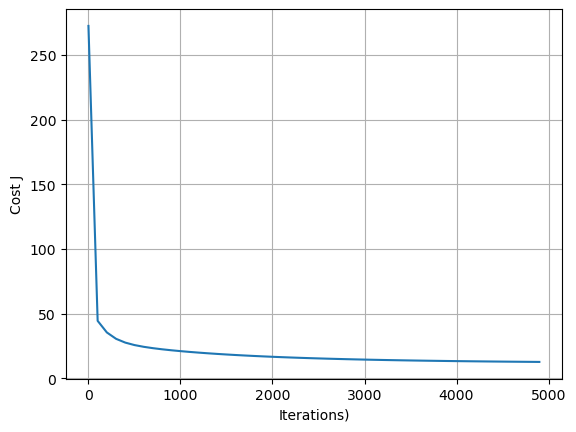

In [72]:
plt.plot(np.arange(0, iters, 100), j_record)
plt.xlabel('Iterations)')
plt.ylabel('Cost J')
plt.grid(True)
plt.show()

## Model Evaluation on Test Data

In [74]:
predictions = model_calc(X_test_scaled, w_final, b_final)
r2 = r2_score(Y_test, predictions)
print(f'Scratch Model R² Score: {r2:.4f} ({r2*100:.2f}%)')


Scratch Model R² Score: 0.7085 (70.85%)


## Comparison with scikit learn 

In [83]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, Y_train)
y_pred = model.predict(X_test_scaled)
r2 = r2_score(Y_test, y_pred)
r2*100

73.3373395082951